# Exploratory Data Analysis
## Evaluating LLM-based RAG for Automating TPRM Vendor Questionnaire Completion

This notebook characterises the two inputs to the evaluation:

1. **Knowledge corpus**, the CMMC 2.0 / NIST SP 800-171 compliance question-answer
   corpus that serves as the retrieval knowledge base.
2. **Test set**, the 75 TPRM-relevant questions, with ground-truth answers, used to
   score the RAG system against a no-context baseline.

The analysis applies several complementary methods: descriptive statistics, term
frequency, word-cloud and *n*-gram analysis, and a domain-specific coverage analysis
that tags each item by compliance framework, NIST control family, and the four
TPRM categories defined in the methodology (access control, incident response,
configuration management, and audit). The structure follows the descriptive-analytics
template used in the program's sample reports: each figure is numbered, captioned,
and accompanied by a short interpretation.

In [1]:
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud

import eda_utils as eda

warnings.filterwarnings("ignore")
eda.set_style()

# --- Paths (edit DATA_DIR / TEST_CSV if the project layout differs) -----------
DATA_DIR = Path("../dataset")
TEST_CSV = Path("../tprm_app/dataset/test_questions.csv")
FIG = Path("figures")
OUT = Path("outputs")
FIG.mkdir(exist_ok=True)
OUT.mkdir(exist_ok=True)

## 1. Data loading and structure

The corpus is stored in chat format: every record is a `system` / `user` / `assistant`
message triple. We flatten each record into a question (the user turn) and an answer
(the assistant turn), keeping the original train / validation split.

In [2]:
corpus = eda.load_corpus(DATA_DIR)
test = eda.load_test_set(TEST_CSV)

corpus["q_words"] = corpus["question"].map(eda.word_count)
corpus["a_words"] = corpus["answer"].map(eda.word_count)
test["q_words"] = test["question"].map(eda.word_count)
test["a_words"] = test["ground_truth"].map(eda.word_count)

n_total = len(corpus)
n_train = int((corpus.split == "train").sum())
n_val = int((corpus.split == "validation").sum())
print(f"Corpus examples : {n_total:,}  (train {n_train:,} / validation {n_val:,})")
print(f"Test questions  : {len(test)}")
print(f"System prompts  : {corpus['system'].nunique()} unique")
corpus.head(3)

Corpus examples : 5,672  (train 5,104 / validation 568)
Test questions  : 75
System prompts  : 1 unique


,split,system,question,answer,q_words,a_words
0,train,You are a CMMC and cybersecurity compliance ex...,Summarize the guidance provided in Computer Se...,ndation for information security across th...,11,157
1,train,You are a CMMC and cybersecurity compliance ex...,Summarize the key provisions of this Rule abou...,"(Response) In the PRIA, we assumed that person...",21,473
2,train,You are a CMMC and cybersecurity compliance ex...,What are the FedRAMP Moderate baseline paramet...,"Under the FedRAMP Moderate baseline, SR-5 (SR-...",10,73


The corpus contains **5,672** question-answer pairs and the evaluation uses **75**
questions. A single, identical system prompt is shared across every corpus record,
so it carries no discriminating information and is excluded from the text analysis
below; the analysis focuses on the question and answer fields.

## 2. Preprocessing and text normalization

The text analysis that follows uses a light, transparent preprocessing pass rather
than heavy normalization, so the figures reflect the corpus much as the retrieval
tool would see it. For the term-frequency and n-gram analysis, text is lowercased,
tokenized on alphabetic tokens, and English stop words are removed (via
scikit-learn's CountVectorizer). Two choices follow the spirit of the source
documents: control identifiers (for example AC-2 and 03.11.01) and domain
punctuation are retained, because they carry compliance meaning and are exactly the
spans a questionnaire answer must reproduce.

We do not silently repair or drop noisy records. The data-quality scan in a later
section instead surfaces truncation, encoding noise, residual HTML entities, and OCR
artifacts so their extent is visible. Truncation is a source-side artifact (text cut
when the original PDFs were chunked) and cannot be recovered; the light helper below
removes only the recoverable noise (HTML entities, OCR glyph markers, redundant
whitespace) and is shown on a couple of examples for illustration.

In [3]:
import html
import re

def clean_text(text):
    # Light, non-destructive cleaning: decode HTML entities, drop OCR glyph
    # markers, and collapse whitespace. Control identifiers and punctuation
    # are preserved because they carry compliance meaning.
    t = html.unescape(str(text))                 # &amp; -> &
    t = re.sub(r"GLYPH\([^)]*\)", "", t)         # remove OCR glyph artifacts
    t = re.sub(r"\s+", " ", t).strip()           # collapse whitespace
    return t

noisy = corpus["answer"].str.contains(r"&amp;|GLYPH", regex=True)
for raw in corpus.loc[noisy, "answer"].head(2):
    print("RAW  :", raw[:150].replace(chr(10), " "))
    print("CLEAN:", clean_text(raw)[:150])
    print()
print(f"Answers with recoverable noise (HTML entity or GLYPH marker): "
      f"{int(noisy.sum())} of {len(corpus)}")

RAW  : ndation  for  information  security across  the  federal  government,  including  a structureGLYPH(cmap:df00),  yet  flexible  approach  for  managing
CLEAN: ndation for information security across the federal government, including a structure, yet flexible approach for managing information security risk ac

RAW  : Identification and Authentication 20  - Precision in Tenninology - Identification and Authentication - Access Control - Availability &amp; Fault Toler
CLEAN: Identification and Authentication 20 - Precision in Tenninology - Identification and Authentication - Access Control - Availability & Fault Tolerance 

Answers with recoverable noise (HTML entity or GLYPH marker): 32 of 5672


For this exploratory stage the analysis runs on the text as-is; producing a single
cleaned, indexing-ready corpus is deferred to the methodology, where the data is
prepared for the retrieval tool.

## 3. Length distributions

Following the descriptive template, we begin with the numeric structure of the
text, the word counts of questions and answers, reported as summary statistics
and as distributions.

In [4]:
len_stats = pd.DataFrame({
    "Corpus question": eda.summary_stats(corpus["q_words"]),
    "Corpus answer": eda.summary_stats(corpus["a_words"]),
    "Test question": eda.summary_stats(test["q_words"]),
    "Test ground truth": eda.summary_stats(test["a_words"]),
}).T
len_stats.to_csv(OUT / "length_summary_stats.csv")
len_stats

,Min.,1st Qu.,Median,Mean,3rd Qu.,Max.
Corpus question,3.0,10.0,14.0,14.7,19.0,41.0
Corpus answer,12.0,77.0,116.0,208.9,395.0,1094.0
Test question,9.0,14.0,15.0,16.4,19.0,26.0
Test ground truth,17.0,51.5,94.0,99.8,139.5,214.0


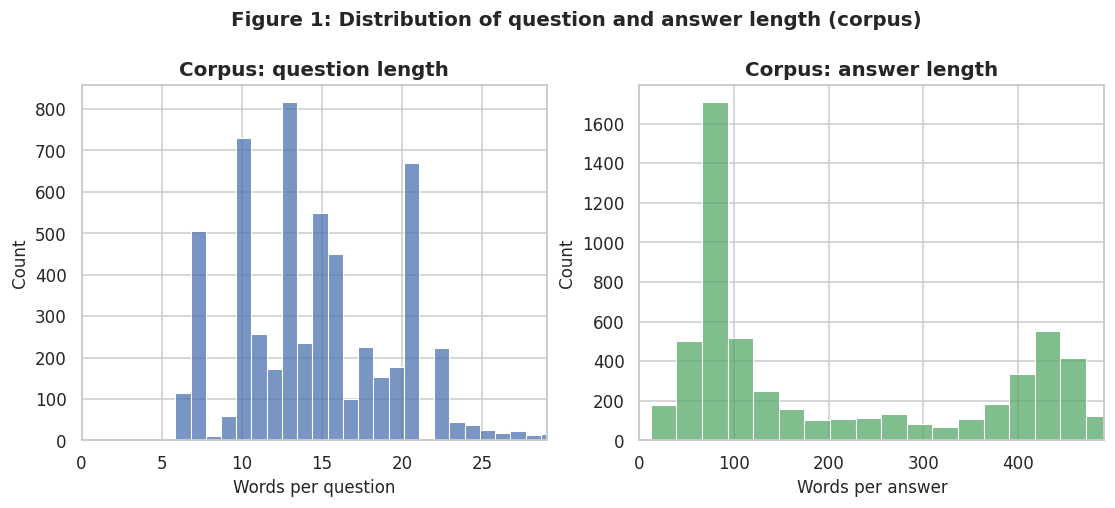

Observation: corpus questions are short (median 14 words), while answers are substantially longer (median 116 words), consistent with retrieval-oriented QA where a concise query maps to a detailed, citable answer.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.histplot(corpus["q_words"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set(title="Corpus: question length", xlabel="Words per question", ylabel="Count")
axes[0].set_xlim(0, corpus["q_words"].quantile(0.99))
sns.histplot(corpus["a_words"], bins=40, ax=axes[1], color="#55A868")
axes[1].set(title="Corpus: answer length", xlabel="Words per answer", ylabel="Count")
axes[1].set_xlim(0, corpus["a_words"].quantile(0.99))
fig.suptitle("Figure 1: Distribution of question and answer length (corpus)", y=1.04, fontsize=13, fontweight="bold")
eda.save_fig(fig, "fig01_corpus_length", FIG)
plt.show()

print(f"Observation: corpus questions are short (median {corpus['q_words'].median():.0f} words), "
      f"while answers are substantially longer (median {corpus['a_words'].median():.0f} words), "
      f"consistent with retrieval-oriented QA where a concise query maps to a detailed, citable answer.")

## 4. Term-frequency analysis

To learn what the corpus is about, we build a document-term matrix over the answer
text (English stop words removed) and rank the most frequent terms.

Document-term matrix: 5,672 documents x 17,788 terms


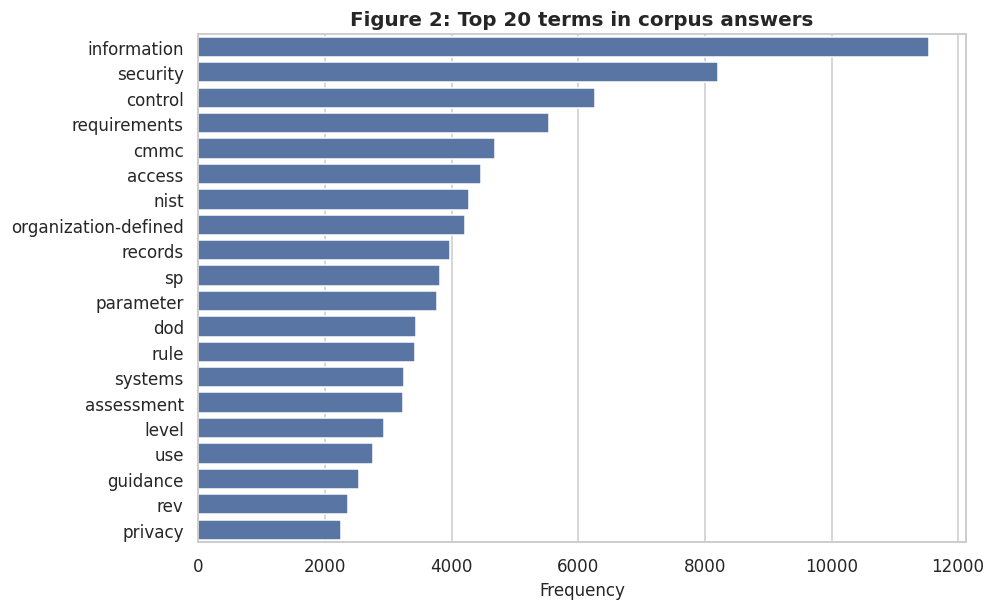

In [6]:
answer_text = corpus["answer"].tolist()
count_vec = CountVectorizer(stop_words="english", token_pattern=r"[A-Za-z][A-Za-z\-]+")
dtm = count_vec.fit_transform(answer_text)
vocab = np.array(count_vec.get_feature_names_out())
freqs = np.asarray(dtm.sum(axis=0)).ravel()
order = freqs.argsort()[::-1]
top_terms = pd.Series(freqs[order][:20], index=vocab[order][:20])

print(f"Document-term matrix: {dtm.shape[0]:,} documents x {dtm.shape[1]:,} terms")

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_terms.values, y=top_terms.index, ax=ax, color="#4C72B0")
ax.set(title="Figure 2: Top 20 terms in corpus answers", xlabel="Frequency", ylabel="")
eda.save_fig(fig, "fig02_top_terms", FIG)
plt.show()

The leading terms, *security*, *control*, *information*, *system*, *requirements*,
*organization*, confirm that the corpus is squarely about security-control
guidance, the substance a TPRM questionnaire response must draw on.

## 5. Word cloud

A word cloud gives a quick, qualitative overview of the same vocabulary.

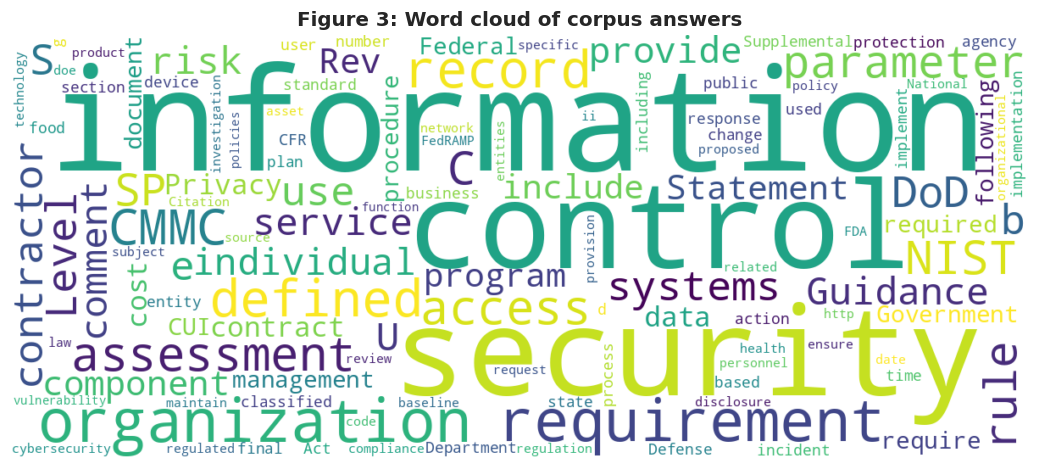

In [7]:
wc = WordCloud(width=1200, height=500, background_color="white",
               colormap="viridis", stopwords=set(ENGLISH_STOP_WORDS),
               max_words=120, collocations=False)
wc.generate(" ".join(answer_text))

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Figure 3: Word cloud of corpus answers", fontsize=13, fontweight="bold")
eda.save_fig(fig, "fig03_wordcloud", FIG)
plt.show()

The word cloud reinforces the term-frequency result: the corpus vocabulary is
dominated by control, system, and assessment language drawn from the NIST control
catalogue.

## 6. N-gram analysis

Unigrams capture topic words; bigrams and trigrams reveal the multi-word phrases (the named controls and standard expressions) that characterise compliance text.

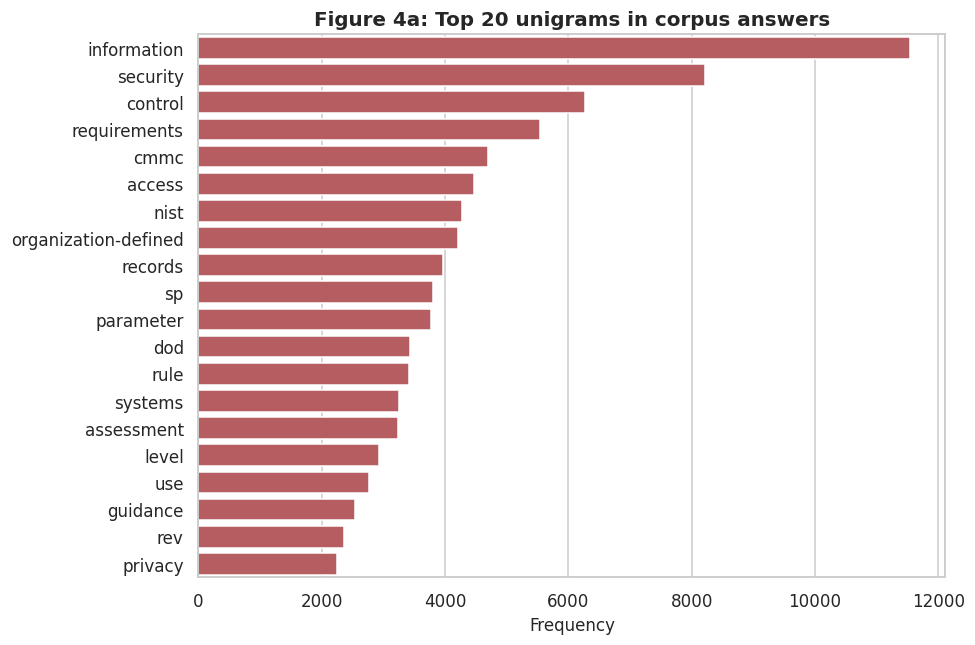

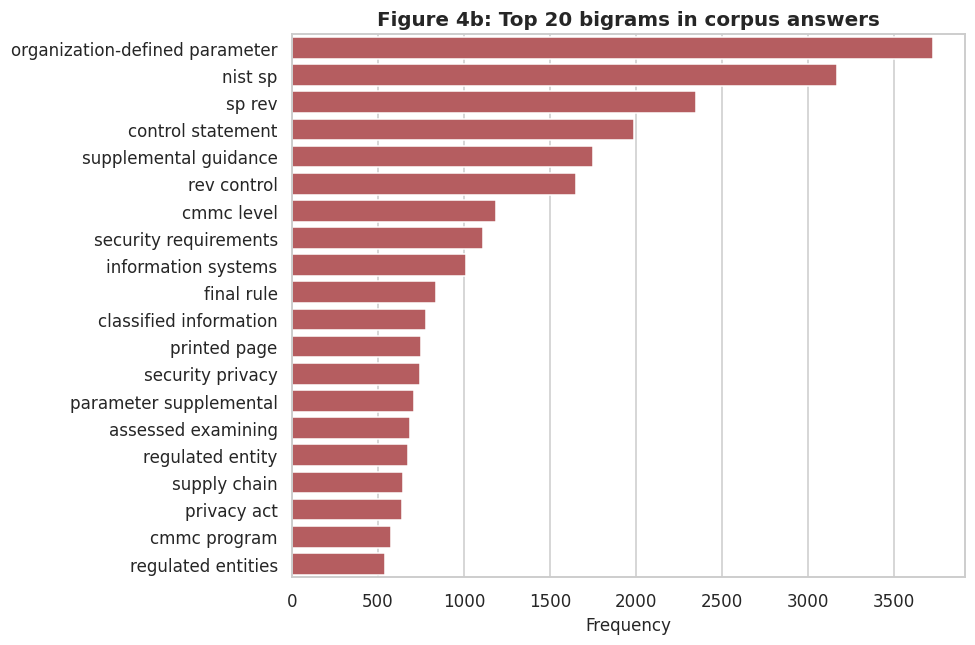

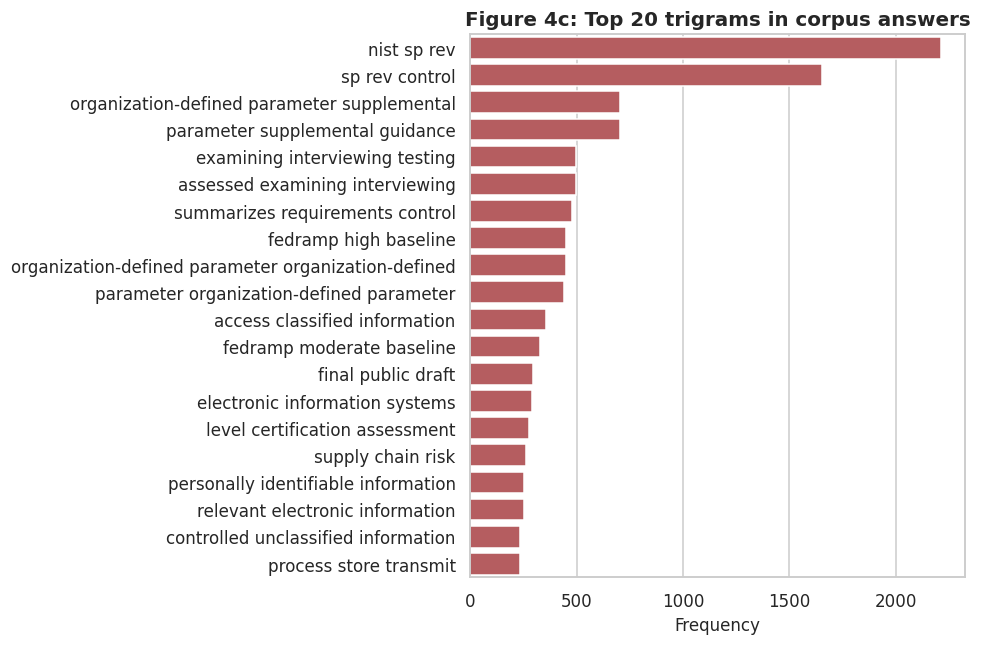

In [8]:
def top_ngrams(texts, n, k=20):
    vec = CountVectorizer(stop_words="english", ngram_range=(n, n),
                          token_pattern=r"[A-Za-z][A-Za-z\-]+")
    matrix = vec.fit_transform(texts)
    names = np.array(vec.get_feature_names_out())
    sums = np.asarray(matrix.sum(axis=0)).ravel()
    idx = sums.argsort()[::-1][:k]
    return pd.Series(sums[idx], index=names[idx])

ngram_configs = [(1, "unigrams", "fig04a_unigrams", "Figure 4a: Top 20 unigrams in corpus answers"),
                 (2, "bigrams",  "fig04b_bigrams",  "Figure 4b: Top 20 bigrams in corpus answers"),
                 (3, "trigrams", "fig04c_trigrams",  "Figure 4c: Top 20 trigrams in corpus answers")]

for n, label, fname, title in ngram_configs:
    s = top_ngrams(answer_text, n)
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.barplot(x=s.values, y=s.index, ax=ax, color="#C44E52")
    ax.set(title=title, xlabel="Frequency", ylabel="")
    fig.tight_layout()
    eda.save_fig(fig, fname, FIG)
    plt.show()


The bigrams and trigrams expose the structured nature of the source material,
phrases such as *access control*, *configuration management*, *security
requirements*, and *organization-defined parameter* recur throughout. These fixed
expressions are precisely the spans a retrieval system must surface verbatim to
answer a questionnaire item correctly.

## 7. Question categorization (intent taxonomy)

Grouping questions by their opening word reveals little. Instead we classify each
question by *what it asks the model to do*, using a small rule-based taxonomy keyed
on the question templates in the corpus: control summaries, requirements lookups,
assessment objectives, vulnerability (CVE) questions, document or standard
overviews, and compliance-implication questions. Applying the same taxonomy to the
corpus and to the test set lets us compare what the knowledge base contains with
what the evaluation actually asks.

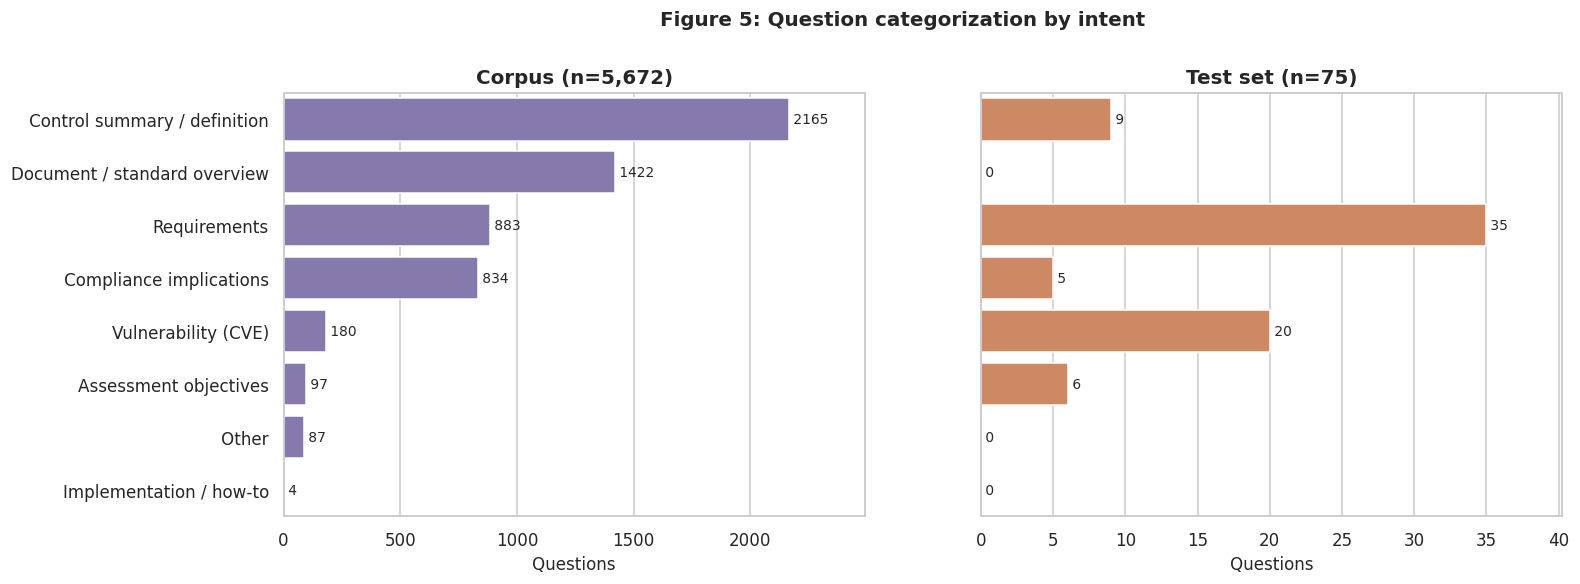

                              corpus  corpus_%  test  test_%
intent                                                      
Control summary / definition    2165      38.2     9    12.0
Document / standard overview    1422      25.1     0     0.0
Requirements                     883      15.6    35    46.7
Compliance implications          834      14.7     5     6.7
Vulnerability (CVE)              180       3.2    20    26.7
Assessment objectives             97       1.7     6     8.0
Other                             87       1.5     0     0.0
Implementation / how-to            4       0.1     0     0.0


In [9]:
corpus["intent"] = corpus["question"].map(eda.classify_question_intent)
test["intent"] = test["question"].map(eda.classify_question_intent)

c_counts = corpus["intent"].value_counts()
t_counts = test["intent"].value_counts()
cat_order = c_counts.sort_values(ascending=False).index.tolist()

intent_table = pd.DataFrame({
    "corpus": c_counts.reindex(cat_order).fillna(0).astype(int),
    "corpus_%": (c_counts.reindex(cat_order) / len(corpus) * 100).round(1),
    "test": t_counts.reindex(cat_order).fillna(0).astype(int),
    "test_%": (t_counts.reindex(cat_order) / len(test) * 100).round(1),
}).fillna(0)
intent_table.to_csv(OUT / "question_intent.csv")

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
panels = [("Corpus", c_counts, "#8172B3", len(corpus)),
          ("Test set", t_counts, "#DD8452", len(test))]
for k, (ax, (label, counts, color, n)) in enumerate(zip(axes, panels)):
    vals = counts.reindex(cat_order).fillna(0).astype(int).values
    sns.barplot(x=vals, y=cat_order, ax=ax, color=color)
    ax.set_xlim(0, max(vals) * 1.15)
    for i, v in enumerate(vals):
        ax.text(v, i, f" {v}", va="center", fontsize=9)
    ax.set(title=f"{label} (n={n:,})", xlabel="Questions", ylabel="")
    if k == 1:
        ax.tick_params(labelleft=False)
fig.suptitle("Figure 5: Question categorization by intent", y=1.03, fontsize=13, fontweight="bold")
eda.save_fig(fig, "fig05_question_intent", FIG)
plt.show()
print(intent_table.to_string())

The corpus is dominated by control summaries and document or standard overviews,
with requirements and compliance-implication questions making up most of the
remainder; procedural how-to questions are almost absent, so the knowledge base is
descriptive rather than instructional. The test set inverts this profile: it is
dominated by requirements lookups and CVE / vulnerability questions. This mismatch
matters, because the evaluation stresses question types that are a minority of the
knowledge base, and that should be kept in view when interpreting retrieval
performance.

## 8. Framework coverage

Each item is tagged with the compliance frameworks it references. This shows the
breadth of the knowledge base.

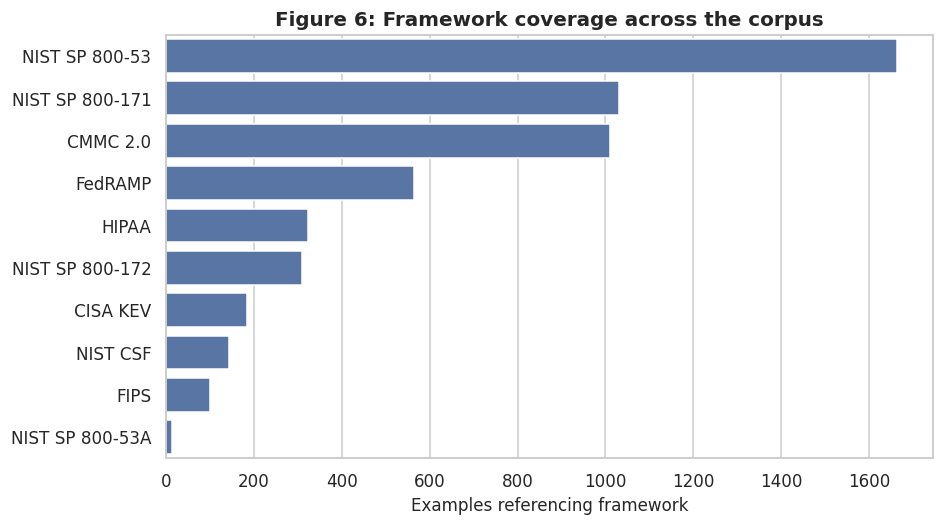

NIST SP 800-53     29.3
NIST SP 800-171    18.2
CMMC 2.0           17.8
FedRAMP            10.0
HIPAA               5.7
NIST SP 800-172     5.4
CISA KEV            3.2
NIST CSF            2.5
FIPS                1.8
NIST SP 800-53A     0.2


In [10]:
corpus_qa = (corpus["question"] + " " + corpus["answer"])
fw_counts = Counter()
for text in corpus_qa:
    for fw in eda.detect_frameworks(text):
        fw_counts[fw] += 1
fw_series = pd.Series(fw_counts).sort_values(ascending=False)
fw_pct = (fw_series / len(corpus) * 100).round(1)
pd.DataFrame({"examples": fw_series, "share_%": fw_pct}).to_csv(OUT / "corpus_framework_coverage.csv")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=fw_series.values, y=fw_series.index, ax=ax, color="#4C72B0")
ax.set(title="Figure 6: Framework coverage across the corpus", xlabel="Examples referencing framework", ylabel="")
eda.save_fig(fig, "fig06_corpus_frameworks", FIG)
plt.show()
print(fw_pct.to_string())

NIST SP 800-53, SP 800-171, and CMMC 2.0 are the dominant frameworks, with
supporting coverage of FedRAMP, HIPAA, and the CISA KEV catalogue. The breadth is
appropriate: TPRM vendor questionnaires routinely map to several of these
standards at once.

## 9. Control-family coverage

Tagging by NIST control family (extracted from the control identifiers in the
text) shows which security domains the corpus covers and how evenly.

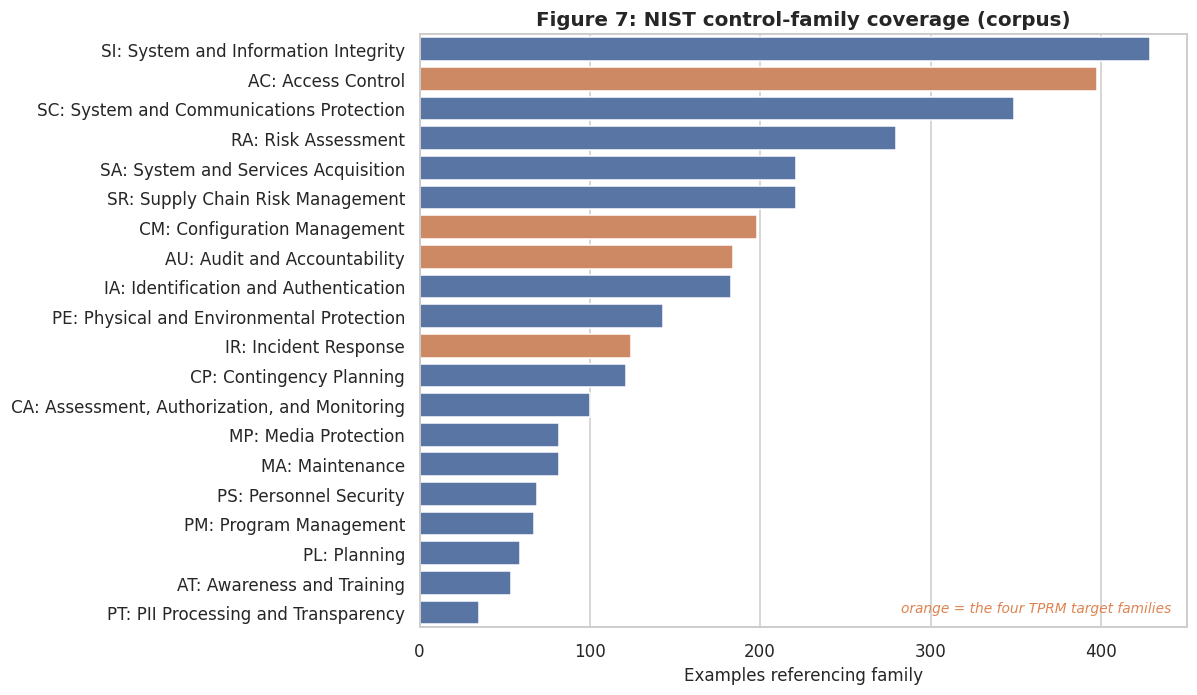

In [11]:
fam_counts = Counter()
for text in corpus_qa:
    for fam in eda.extract_families(text):
        fam_counts[fam] += 1
fam_series = pd.Series(fam_counts).sort_values(ascending=False)
fam_labels = [f"{code}: {eda.FAMILY_NAMES.get(code, code)}" for code in fam_series.index]
pd.DataFrame({"family": fam_series.index, "name": [eda.FAMILY_NAMES.get(c, c) for c in fam_series.index],
              "examples": fam_series.values}).to_csv(OUT / "corpus_family_coverage.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#DD8452" if c in eda.TPRM_CATEGORIES else "#4C72B0" for c in fam_series.index]
sns.barplot(x=fam_series.values, y=fam_labels, ax=ax, palette=colors)
ax.set(title="Figure 7: NIST control-family coverage (corpus)", xlabel="Examples referencing family", ylabel="")
ax.text(0.98, 0.02, "orange = the four TPRM target families", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=9, style="italic", color="#DD8452")
eda.save_fig(fig, "fig07_corpus_families", FIG)
plt.show()

All eighteen control families appear. System and Information Integrity (SI), Access
Control (AC), and System and Communications Protection (SC) are the most heavily
represented. Crucially, the four families that anchor the TPRM test set, Access
Control, Audit and Accountability, Configuration Management, and Incident Response
(highlighted), are all well covered, so the knowledge base can in principle
support the questionnaire items the evaluation targets.

## 10. Data quality and corpus noise

Because the corpus is the RAG knowledge base, any text-quality defect propagates
directly into retrieved answers. We first check for exact duplicates, then for
truncated answers (no terminal punctuation), residual HTML entities, OCR artifacts,
and non-ASCII characters left over from PDF extraction.

In [12]:
dup_q = corpus["question"].duplicated().sum()
dup_qa = corpus.duplicated(subset=["question", "answer"]).sum()
print(f"Duplicate questions (exact)        : {dup_q}")
print(f"Duplicate question+answer pairs    : {dup_qa}")
print(f"Unique questions                   : {corpus['question'].nunique():,} of {len(corpus):,}")

Duplicate questions (exact)        : 1887
Duplicate question+answer pairs    : 0
Unique questions                   : 3,785 of 5,672


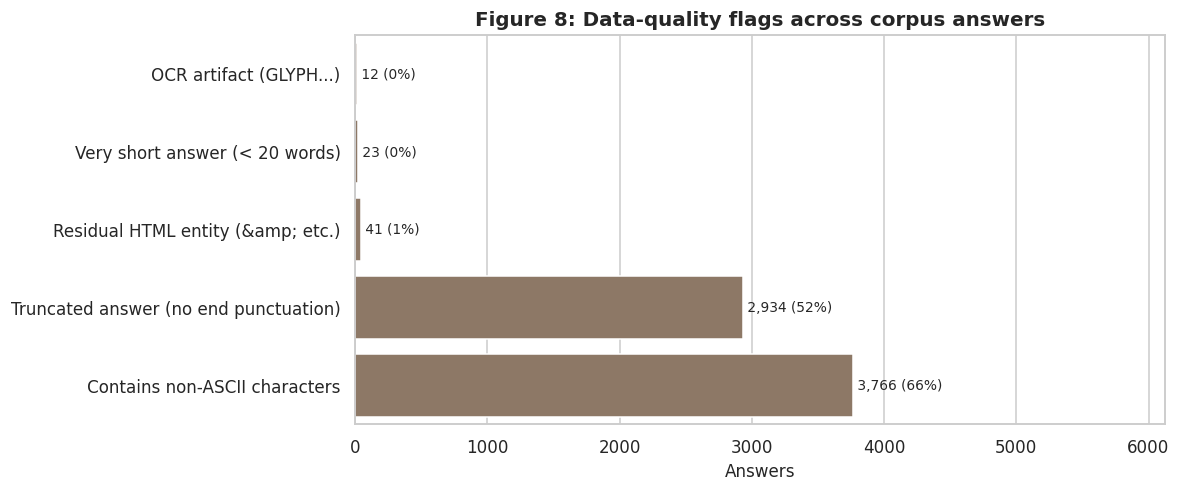

                                       answers  share_%
Truncated answer (no end punctuation)     2934     51.7
Contains non-ASCII characters             3766     66.4
Very short answer (< 20 words)              23      0.4
Residual HTML entity (&amp; etc.)           41      0.7
OCR artifact (GLYPH...)                     12      0.2


In [13]:
answers = corpus["answer"]
n = len(corpus)
last_char = answers.str.rstrip().str[-1]
end_ok = [".", "!", "?", ":", ")", '"']
n_truncated = int((~last_char.isin(end_ok)).sum())

quality = {
    "Truncated answer (no end punctuation)": n_truncated,
    "Contains non-ASCII characters": int(answers.map(lambda s: any(ord(ch) > 127 for ch in str(s))).sum()),
    "Very short answer (< 20 words)": int((answers.str.split().map(len) < 20).sum()),
    "Residual HTML entity (&amp; etc.)": int(answers.str.contains(r"&amp;|&lt;|&gt;|&#", regex=True).sum()),
    "OCR artifact (GLYPH...)": int(answers.str.contains("GLYPH").sum()),
}
qdf = pd.DataFrame({"answers": pd.Series(quality)})
qdf["share_%"] = (qdf["answers"] / n * 100).round(1)
qdf.to_csv(OUT / "corpus_data_quality.csv")

s = pd.Series(quality).sort_values()
fig, ax = plt.subplots(figsize=(9.5, 4.6))
sns.barplot(x=s.values, y=s.index, ax=ax, color="#937860")
for i, v in enumerate(s.values):
    ax.text(v, i, f" {v:,} ({v / n * 100:.0f}%)", va="center", fontsize=9)
ax.set(title="Figure 8: Data-quality flags across corpus answers", xlabel="Answers", ylabel="")
ax.set_xlim(0, n * 1.08)
eda.save_fig(fig, "fig08_data_quality", FIG)
plt.show()
print(qdf.to_string())

Roughly half of corpus answers lack terminal punctuation, indicating they were
truncated where the source documents were chunked, and about two-thirds contain
non-ASCII characters (largely smart quotes and bullet glyphs from PDF extraction);
a small number carry residual HTML entities or OCR artifacts. None of this is fatal
and the corpus remains usable, but truncated and noisy passages cap the achievable
answer quality and likely explain part of any residual gap between the RAG output
and the ground truth. These limitations should be noted in the methodology, and the
worst artifacts trimmed before indexing if time allows.

# Part II: The evaluation test set

The remaining sections characterise the 75-question test set: its difficulty
balance, length, and, most importantly for the methodology, how well it covers
the four target TPRM categories and how representative it is of the corpus.

## 11. Difficulty balance and length

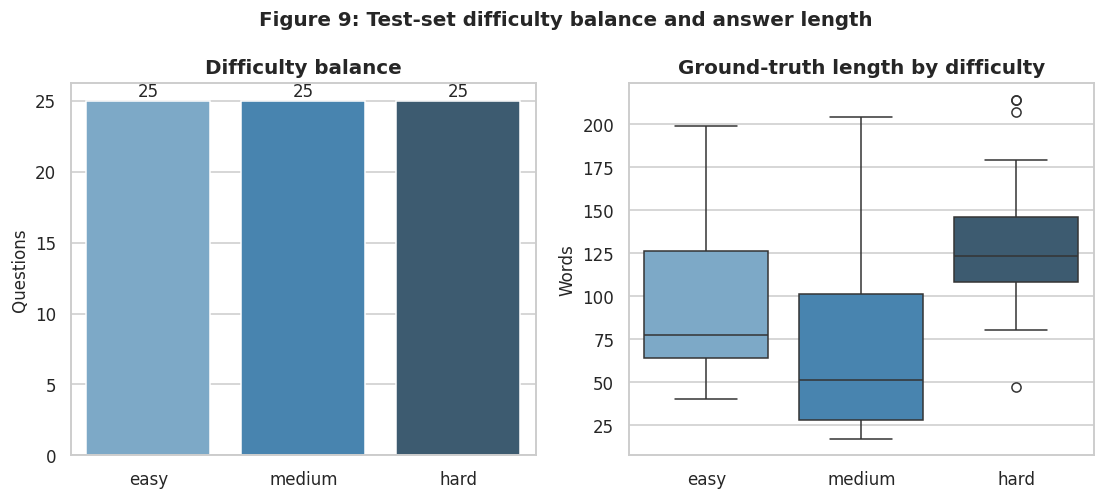

             mean  median  max
difficulty                    
easy         95.3    77.0  199
hard        131.6   123.0  214
medium       72.6    51.0  204


In [14]:
diff_order = ["easy", "medium", "hard"]
diff_counts = test["difficulty"].value_counts().reindex(diff_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
sns.barplot(x=diff_counts.index, y=diff_counts.values, ax=axes[0], palette="Blues_d")
axes[0].set(title="Difficulty balance", xlabel="", ylabel="Questions")
for i, v in enumerate(diff_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha="center")
sns.boxplot(data=test, x="difficulty", y="a_words", order=diff_order, ax=axes[1], palette="Blues_d")
axes[1].set(title="Ground-truth length by difficulty", xlabel="", ylabel="Words")
fig.suptitle("Figure 9: Test-set difficulty balance and answer length", y=1.03, fontsize=13, fontweight="bold")
eda.save_fig(fig, "fig09_test_difficulty", FIG)
plt.show()

print(test.groupby("difficulty")["a_words"].agg(["mean", "median", "max"]).round(1).to_string())

The test set is balanced by design, 25 easy, 25 medium, and 25 hard questions.
Ground-truth length increases with difficulty, with hard items carrying the longest
reference answers (these include the CVE / vulnerability-management questions whose
answers contain detailed remediation guidance).

## 12. Framework and control-family coverage of the test set

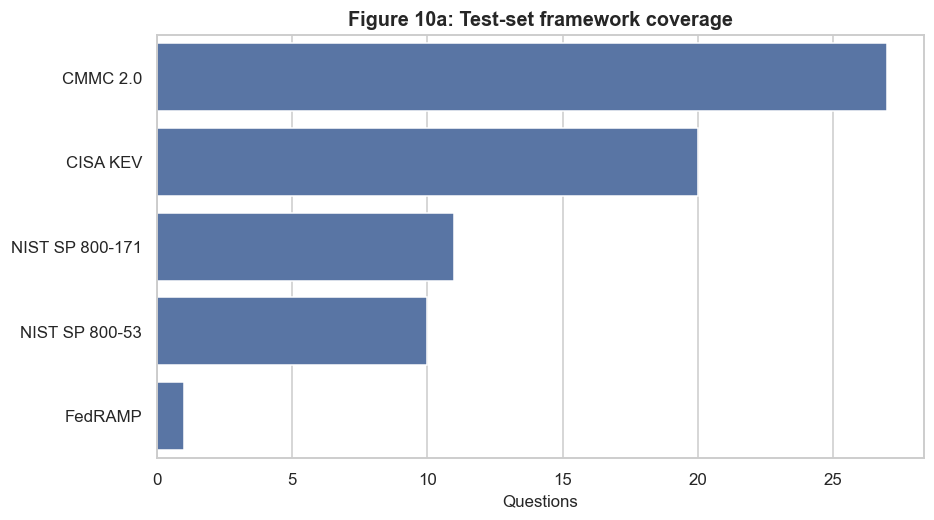

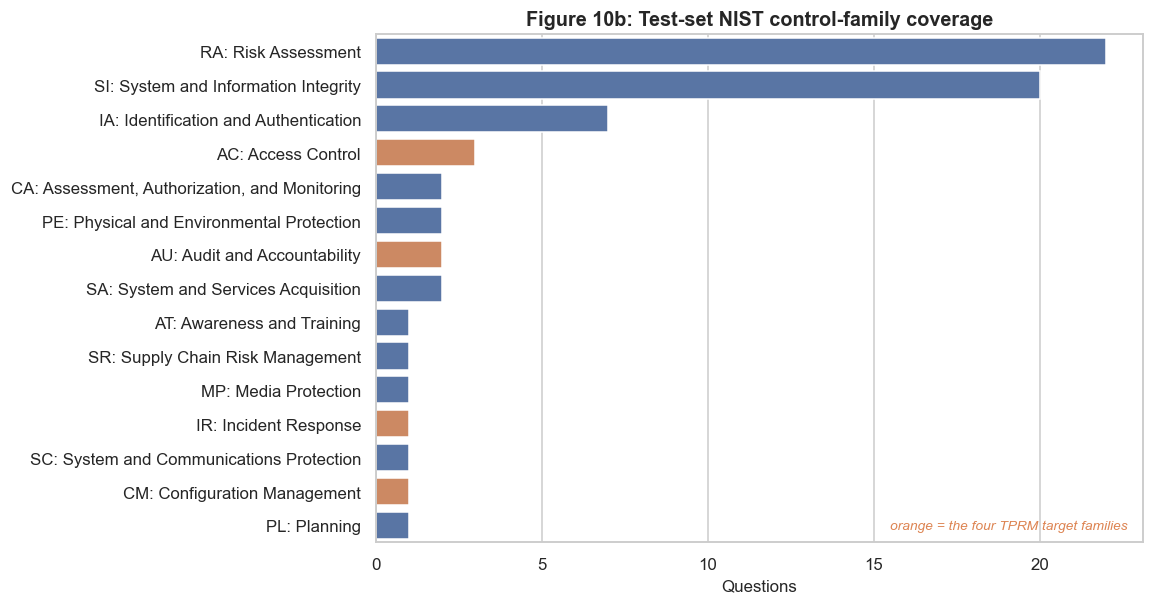

In [38]:
test_qa = (test["question"] + " " + test["ground_truth"])

t_fw = Counter()
for text in test_qa:
    for fw in eda.detect_frameworks(text):
        t_fw[fw] += 1
t_fw_series = pd.Series(t_fw).sort_values(ascending=False)

t_fam = Counter()
for text in test_qa:
    for fam in eda.extract_families(text):
        t_fam[fam] += 1
t_fam_series = pd.Series(t_fam).sort_values(ascending=False)

# Figure 10a: frameworks referenced by the test set
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=t_fw_series.values, y=t_fw_series.index, ax=ax, color="#4C72B0")
ax.set(title="Figure 10a: Test-set framework coverage", xlabel="Questions", ylabel="")
eda.save_fig(fig, "fig10a_test_frameworks", FIG)
plt.show()

# Figure 10b: NIST control families referenced by the test set
fam_lbl = [f"{c}: {eda.FAMILY_NAMES.get(c, c)}" for c in t_fam_series.index]
colors = ["#DD8452" if c in eda.TPRM_CATEGORIES else "#4C72B0" for c in t_fam_series.index]
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=t_fam_series.values, y=fam_lbl, ax=ax, palette=colors)
ax.set(title="Figure 10b: Test-set NIST control-family coverage", xlabel="Questions", ylabel="")
ax.text(0.98, 0.02, "orange = the four TPRM target families", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=9, style="italic", color="#DD8452")
eda.save_fig(fig, "fig10b_test_families", FIG)
plt.show()

The test set leans on Risk Assessment (RA) and System and Information Integrity
(SI), the latter driven by the CVE / vulnerability questions, with Access Control
and the other target families appearing less often. This is an early indication
that the test set, as currently built, is broader than the four nominal TPRM
categories.

## 13. TPRM category coverage

This is the central methodological check: how many test questions fall into each of
the four declared TPRM categories (access control, incident response, configuration management, and audit) versus other domains. Each question is tagged
from its text and ground-truth answer.

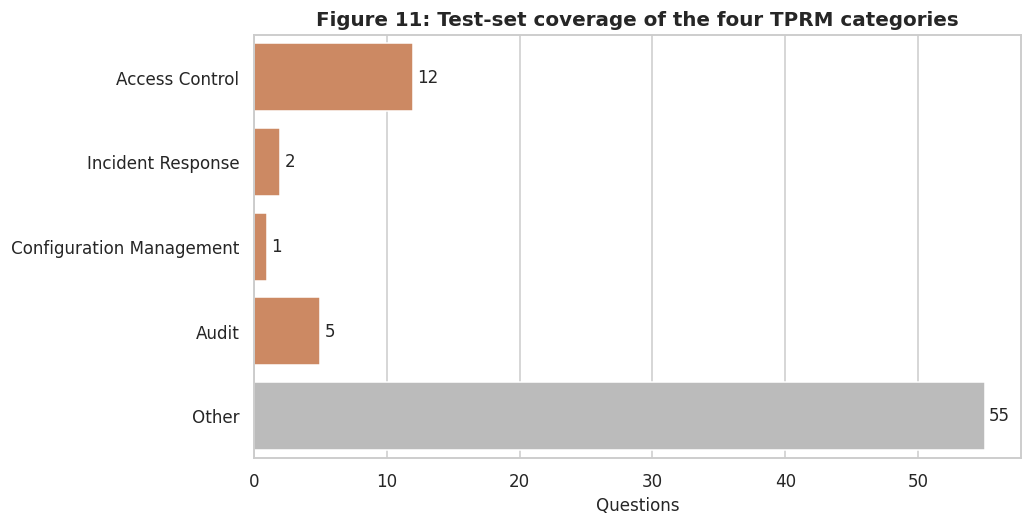

Questions mapping to a target TPRM category : 20 of 75
Questions outside the four categories       : 55
tprm
Access Control              12
Incident Response            2
Configuration Management     1
Audit                        5
Other                       55


In [16]:
test["tprm"] = test_qa.map(eda.primary_tprm_category)
cat_order = ["Access Control", "Incident Response", "Configuration Management", "Audit", "Other"]
cat_counts = test["tprm"].value_counts().reindex(cat_order).fillna(0).astype(int)
cat_counts.to_csv(OUT / "test_tprm_category_coverage.csv")

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#DD8452"] * 4 + ["#BBBBBB"]
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=ax, palette=colors)
for i, v in enumerate(cat_counts.values):
    ax.text(v + 0.3, i, str(v), va="center")
ax.set(title="Figure 11: Test-set coverage of the four TPRM categories", xlabel="Questions", ylabel="")
eda.save_fig(fig, "fig11_tprm_categories", FIG)
plt.show()

in_scope = int(cat_counts[cat_order[:4]].sum())
print(f"Questions mapping to a target TPRM category : {in_scope} of {len(test)}")
print(f"Questions outside the four categories       : {len(test) - in_scope}")
print(cat_counts.to_string())

A substantial share of questions map outside the four declared categories. This is
the most important finding of the EDA and warrants a decision before the evaluation
is run: either (a) re-scope the test set so it concentrates on access control,
incident response, configuration management, and audit, as the methodology states,
or (b) broaden the methodology's stated category framing to match the wider control
coverage the current test set exercises. The choice affects how the results should
be interpreted and reported.

## 14. Representativeness: test set vs. corpus

We compare the control-family mix of the test set with that of the corpus to judge
whether the test questions exercise the knowledge base in proportion to its content.

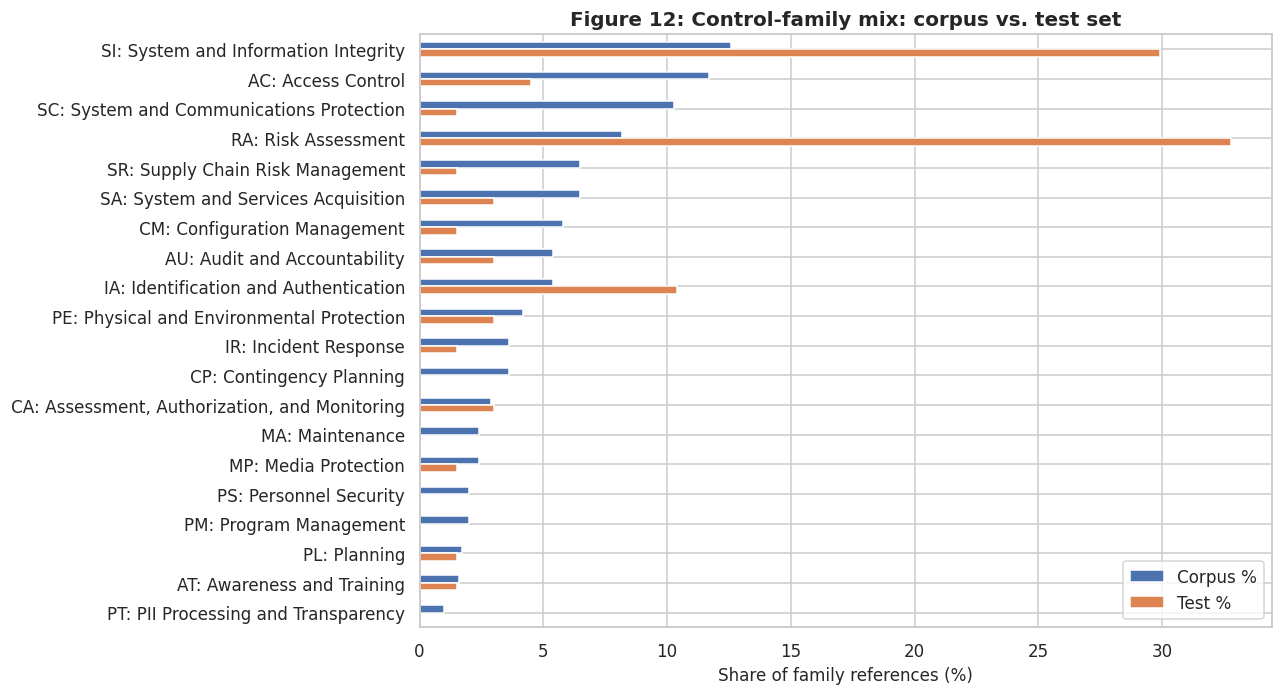

In [17]:
corpus_share = (fam_series / fam_series.sum() * 100)
test_share = (t_fam_series / t_fam_series.sum() * 100)
common = sorted(set(corpus_share.index) | set(test_share.index),
                key=lambda c: corpus_share.get(c, 0), reverse=True)
comp = pd.DataFrame({
    "Corpus %": [round(corpus_share.get(c, 0), 1) for c in common],
    "Test %": [round(test_share.get(c, 0), 1) for c in common],
}, index=[f"{c}: {eda.FAMILY_NAMES.get(c, c)}" for c in common])

fig, ax = plt.subplots(figsize=(10, 7))
comp.plot.barh(ax=ax, color=["#4C72B0", "#DD8452"])
ax.invert_yaxis()
ax.set(title="Figure 12: Control-family mix: corpus vs. test set", xlabel="Share of family references (%)", ylabel="")
eda.save_fig(fig, "fig12_representativeness", FIG)
plt.show()
comp.to_csv(OUT / "representativeness_corpus_vs_test.csv")

The test set over-weights Risk Assessment and System and Information Integrity
relative to the corpus and under-weights several families the corpus emphasises
(e.g. SC, SR). A test set intended to evaluate questionnaire automation broadly
would ideally track the corpus distribution more closely; the divergence should be
acknowledged when interpreting aggregate scores.

## 15. Corpus-test leakage check

If a test question appears verbatim (or near-verbatim) in the corpus, a
retrieval system could return the stored answer directly, inflating its apparent
advantage over the no-context baseline. We measure the maximum TF-IDF cosine
similarity between each test question and every corpus question.

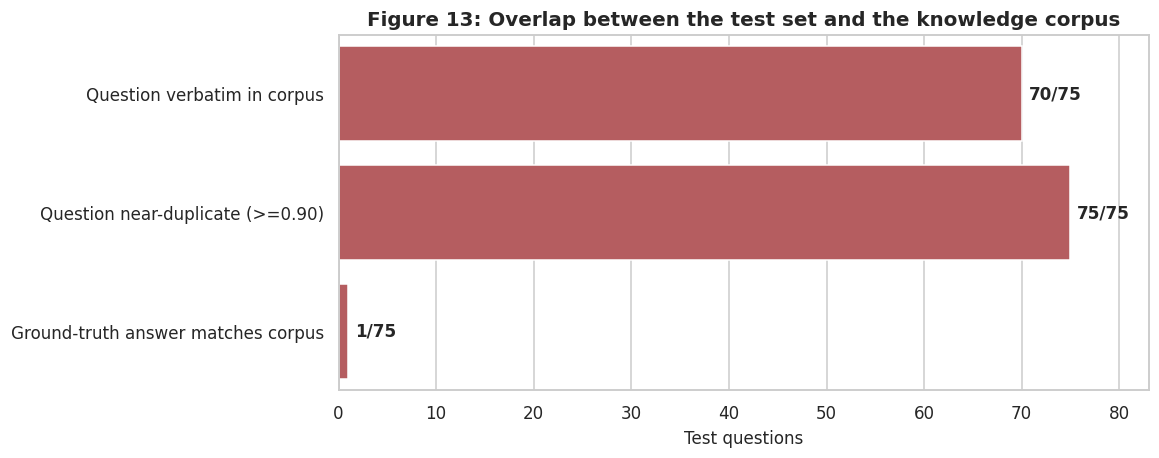

Verbatim test questions in corpus        : 70 of 75
Near-duplicate (cosine >= 0.90)          : 75 of 75
Ground-truth answers reused from corpus  : 1 of 75
Min / median max-similarity              : 1.000 / 1.000


In [18]:
corpus_q = corpus["question"].tolist()
tfidf = TfidfVectorizer(stop_words="english").fit(corpus_q + test["question"].tolist())
sims = cosine_similarity(tfidf.transform(test["question"].tolist()), tfidf.transform(corpus_q))
max_sim = sims.max(axis=1)

q_norm_corpus = set(corpus["question"].str.strip().str.lower())
exact = int(test["question"].str.strip().str.lower().isin(q_norm_corpus).sum())
near = int((max_sim >= 0.9).sum())

# Are the ground-truth answers also reused from the corpus, or independent?
qa_lookup = dict(zip(corpus["question"].str.strip().str.lower(),
                     corpus["answer"].str.strip().str.lower()))
answer_reused = int(sum(
    qa_lookup.get(q) == gt
    for q, gt in zip(test["question"].str.strip().str.lower(),
                     test["ground_truth"].str.strip().str.lower())))

overlap = pd.Series({
    "Question verbatim in corpus": exact,
    "Question near-duplicate (>=0.90)": near,
    "Ground-truth answer matches corpus": answer_reused,
})
fig, ax = plt.subplots(figsize=(9.5, 4.2))
sns.barplot(x=overlap.values, y=overlap.index, ax=ax, color="#C44E52")
for i, v in enumerate(overlap.values):
    ax.text(v + 0.7, i, f"{v}/{len(test)}", va="center", fontweight="bold")
ax.set(title="Figure 13: Overlap between the test set and the knowledge corpus",
       xlabel="Test questions", ylabel="")
ax.set_xlim(0, len(test) + 8)
eda.save_fig(fig, "fig13_leakage", FIG)
plt.show()

print(f"Verbatim test questions in corpus        : {exact} of {len(test)}")
print(f"Near-duplicate (cosine >= 0.90)          : {near} of {len(test)}")
print(f"Ground-truth answers reused from corpus  : {answer_reused} of {len(test)}")
print(f"Min / median max-similarity              : {max_sim.min():.3f} / {np.median(max_sim):.3f}")

This is the single most consequential finding of the EDA. Nearly every test
question is drawn directly from the knowledge corpus, almost all are verbatim and
all are near-duplicates, yet the ground-truth answers are largely *independent* of
the corpus answers (they appear to be separately curated, and are often shorter or
truncated). Two implications follow.

First, because the questions are in the knowledge base, the retriever can locate a
highly relevant passage for essentially every item; the evaluation therefore
measures retrieval-and-synthesis over *seen* material rather than generalisation to
unseen questions, and the RAG-versus-baseline gap should be interpreted in that
light. Second, because the ground-truth answers are not simply the stored corpus
answers, the task is not a trivial lookup: the system must still reproduce the
reference content, so the metrics remain meaningful. Both points should be stated
explicitly in the methodology and discussion, and reported alongside the headline
ROUGE-L and BERTScore results so the comparison is read fairly.

## 16. Summary of findings

*The cell below collates the headline numbers; the narrative summary is recorded in
`outputs/eda_findings.md`.*

In [19]:
summary = {
    "corpus_examples": int(n_total),
    "corpus_train": int(n_train),
    "corpus_validation": int(n_val),
    "corpus_unique_questions": int(corpus["question"].nunique()),
    "corpus_median_q_words": float(corpus["q_words"].median()),
    "corpus_median_a_words": float(corpus["a_words"].median()),
    "vocabulary_terms": int(dtm.shape[1]),
    "test_questions": int(len(test)),
    "test_in_scope_tprm": int(in_scope),
    "test_out_of_scope": int(len(test) - in_scope),
    "leakage_exact": int(exact),
    "leakage_near_dup": int(near),
    "leakage_answer_reused": int(answer_reused),
    "corpus_truncated_answers": int(n_truncated),
}
pd.Series(summary).to_csv(OUT / "eda_summary_metrics.csv")
pd.Series(summary)

corpus_examples              5672.0
corpus_train                 5104.0
corpus_validation             568.0
corpus_unique_questions      3785.0
corpus_median_q_words          14.0
corpus_median_a_words         116.0
vocabulary_terms            17788.0
test_questions                 75.0
test_in_scope_tprm             20.0
test_out_of_scope              55.0
leakage_exact                  70.0
leakage_near_dup               75.0
leakage_answer_reused           1.0
corpus_truncated_answers     2934.0
dtype: float64